# Nettoyage des données

## Import des bibliothèques

In [1]:
import pandas as pd
import os
import glob
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Import du dataset

In [2]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"

try:
    path_dataset = next(repertoire_data_processed.glob("01_dataset_jointure.csv"))
    print(f"Fichier trouvé : {path_dataset}")
    
    # Lecture
    df = pd.read_csv(path_dataset)
except StopIteration:
    print("Erreur : Le fichier 'dataset.csv' est introuvable dans le dossier.")

Fichier trouvé : /home/julien/Repos/fil_rouge-etude_chomage_france/data/processed/01_dataset_jointure.csv


In [3]:
df

,date,annee,trimestre,mois,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,...,ipc,isj,ipc_energie_only,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel,pib,ict,nb_defaillances_entreprise,nb_interimaires
0,1990-01-01,1990,1,1,8.1,6.3,10.3,16.9,6.9,5.1,...,NaN,NaN,NaN,115.7,NaN,1.0,388956.0,NaN,3998.0,NaN
1,1990-02-01,1990,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,113.5,NaN,0.9,NaN,NaN,3815.0,NaN
2,1990-03-01,1990,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,111.5,NaN,0.9,NaN,NaN,4304.0,NaN
3,1990-04-01,1990,2,4,8.0,6.3,10.2,16.8,6.8,5.1,...,NaN,NaN,NaN,110.9,NaN,0.7,391046.0,NaN,3506.0,NaN
4,1990-05-01,1990,2,5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,110.7,NaN,0.9,NaN,NaN,3744.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,2025-10-01,2025,4,10,7.9,8.1,7.6,21.5,6.9,5.1,...,0.9,1.2,-5.6,96.5,94.7,-0.5,NaN,NaN,6364.0,NaN
432,2025-11-01,2025,4,11,NaN,NaN,NaN,NaN,NaN,NaN,...,0.9,1.0,-4.6,97.7,96.4,-0.3,NaN,NaN,NaN,NaN
433,2025-12-01,2025,4,12,NaN,NaN,NaN,NaN,NaN,NaN,...,0.8,NaN,-6.8,98.7,94.5,0.1,NaN,NaN,NaN,NaN
434,2026-01-01,2026,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns

Index(['date', 'annee', 'trimestre', 'mois', 'taux_chomage_total_insee',
       'taux_chomage_homme_insee', 'taux_chomage_femme_insee',
       'taux_chomage_15_24_insee', 'taux_chomage_25_49_insee',
       'taux_chomage_50_plus_insee', 'demandeur_total_abcd_total',
       'demandeur_homme_abcd_total', 'demandeur_femme_abcd_total',
       'demandeur_total_abcd_moins25', 'demandeur_total_abcd_2549',
       'demandeur_total_abcd_plus50', 'demandeur_homme_abcd_moins25',
       'demandeur_homme_abcd_2549', 'demandeur_homme_abcd_plus50',
       'demandeur_femme_abcd_moins25', 'demandeur_femme_abcd_2549',
       'demandeur_femme_abcd_plus50', 'nb_offres_france_travail',
       'population_active', 'taux_chomage_insee', 'taux_chomage_ocde',
       'taux_euribor_3m', 'mro', 'ipc', 'isj', 'ipc_energie_only',
       'indicateur_climat_affaires', 'indicateur_climat_emploi',
       'indicateur_retournement_conjoncturel', 'pib', 'ict',
       'nb_defaillances_entreprise', 'nb_interimaires'],
      d

## Type de données

In [5]:
df.dtypes

date                                        str
annee                                     int64
trimestre                                 int64
mois                                      int64
taux_chomage_total_insee                float64
taux_chomage_homme_insee                float64
taux_chomage_femme_insee                float64
taux_chomage_15_24_insee                float64
taux_chomage_25_49_insee                float64
taux_chomage_50_plus_insee              float64
demandeur_total_abcd_total              float64
demandeur_homme_abcd_total              float64
demandeur_femme_abcd_total              float64
demandeur_total_abcd_moins25            float64
demandeur_total_abcd_2549               float64
demandeur_total_abcd_plus50             float64
demandeur_homme_abcd_moins25            float64
demandeur_homme_abcd_2549               float64
demandeur_homme_abcd_plus50             float64
demandeur_femme_abcd_moins25            float64
demandeur_femme_abcd_2549               

Commentaires : 
- Toutes les variables sont au format Float
- à noter que "dteday" est défini comme un objet. On peut le transformer en un timestamp

### Conversion de la colonne date au format datetime

In [6]:
df['date'] = pd.to_datetime(df['date'])

### Description du dataset

In [7]:
df.describe()

,date,annee,trimestre,mois,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,...,ipc,isj,ipc_energie_only,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel,pib,ict,nb_defaillances_entreprise,nb_interimaires
count,436,436.000000,436.000000,436.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,...,422.000000,421.000000,422.000000,434.000000,422.000000,434.000000,145.000000,113.000000,432.000000,103.000000
mean,2007-12-31 18:06:36.330275,2007.545872,2.486239,6.451835,8.975342,8.468493,9.573973,21.575342,8.093836,5.752055,...,1.685308,1.478860,3.230095,100.092857,100.009479,0.182811,529179.234483,85.636283,4471.835648,661273.427517
min,1990-01-01 00:00:00,1990.000000,1.000000,1.000000,7.100000,6.300000,6.800000,16.500000,6.300000,4.100000,...,-0.700000,-0.100000,-18.300000,45.700000,42.000000,-1.000000,388956.000000,60.300000,703.000000,477838.210451
25%,1999-01-01 00:00:00,1999.000000,1.000000,3.000000,8.000000,7.600000,8.700000,19.025000,7.200000,5.100000,...,0.900000,0.700000,-1.500000,94.625000,94.000000,-0.700000,459345.000000,74.100000,3964.250000,593762.607550
50%,2007-12-16 12:00:00,2007.500000,2.000000,6.000000,9.000000,8.400000,9.600000,21.850000,8.100000,5.750000,...,1.600000,1.200000,2.050000,101.250000,100.950000,0.700000,546199.000000,88.200000,4684.500000,640411.444797
75%,2017-01-08 18:00:00,2017.000000,3.000000,9.000000,10.075000,9.275000,10.300000,23.800000,9.100000,6.400000,...,2.100000,1.700000,7.875000,107.100000,107.200000,0.900000,590306.000000,96.400000,5369.750000,730857.542042
max,2026-02-01 00:00:00,2026.000000,4.000000,12.000000,10.700000,11.000000,12.100000,27.900000,9.800000,7.200000,...,6.300000,6.100000,33.100000,121.000000,120.000000,1.000000,661062.000000,112.800000,6897.000000,821378.102512
std,NaN,10.443948,1.123334,3.476684,1.082370,1.169129,1.409429,2.983438,1.031117,0.741408,...,1.188293,1.127093,7.499034,9.920619,9.977588,0.819373,81043.124941,14.409341,1240.152331,89845.599252


Commentaire : ATTENTION aux variables d'indices !!!

- indicateur_retournement_conjoncturel
- ipc_energie_only
- ipc
- isj

à recalculer en premier lieu !

# Valeurs manquantes

### La problématique

Nous avons de nombreuses sources de données, chacune présentant des périodes et des fréquences de mises à jour différentes.

| Titre (Variable) | Fréquence | Date début | Date fin |
| :--- | :--- | :--- | :--- |
| Taux de chômage total INSEE (`taux_chomage_total_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage Homme INSEE (`taux_chomage_homme_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage Femme INSEE (`taux_chomage_femme_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 15-24 ans INSEE (`taux_chomage_15_24_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 25-49 ans INSEE (`taux_chomage_25_49_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| Taux de chômage 50 ans et plus INSEE (`taux_chomage_50_plus_insee`) | Trimestrielle | 01/01/1975 | 31/12/2025 |
| DEFM Total ABCDE (`demandeur_total_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes ABCDE (`demandeur_homme_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes ABCDE (`demandeur_femme_abcd_total`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM -25 ans ABCDE (`demandeur_total_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM 25-49 ans ABCDE (`demandeur_total_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM 50 ans et plus ABCDE (`demandeur_total_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes -25 ans ABCDE (`demandeur_homme_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes 25-49 ans ABCDE (`demandeur_homme_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Hommes 50 ans+ ABCDE (`demandeur_homme_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes -25 ans ABCDE (`demandeur_femme_abcd_moins25`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes 25-49 ans ABCDE (`demandeur_femme_abcd_2549`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| DEFM Femmes 50 ans+ ABCDE (`demandeur_femme_abcd_plus50`) | Trimestrielle | 01/01/1996 | 30/06/2025 |
| Offres d'emploi France Travail (`nb_offres_france_travail`) | Mensuelle | 01/01/2015 | 30/09/2025 |
| Population active (OIT) (`population_active`) | Annuelle | 01/01/1990 | 31/12/2024 |
| Taux de chômage (INSEE) (`taux_chomage_insee`) | Annuelle | 01/01/1975 | 31/12/2024 |
| Taux de chômage (OCDE) (`taux_chomage_ocde`) | Mensuelle | 01/01/1990 | 31/10/2025 |
| Euribor 3-month (`taux_euribor_3m`) | Mensuelle | 31/01/1994 | 31/12/2025 |
| Main refinancing operations (`MRO`) | Ponctuelle | 01/01/1999 | 11/06/2025 |
| Indice des prix à la consommation (`ipc`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| Inflation sous-jacente (`isj`) | Mensuelle | 01/01/1991 | 30/11/2025 |
| IPC ENERGIE (`ipc_energie_only`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| Climat des affaires (`indicateur_climat_affaires`) | Mensuelle | 01/01/1977 | 31/12/2025 |
| Climat de l'emploi (`indicateur_climat_emploi`) | Mensuelle | 01/01/1991 | 31/12/2025 |
| Retournement conjoncturel (`indicateur_retournement_conjoncturel`) | Mensuelle | 01/01/1988 | 31/12/2025 |
| Produit intérieur brut total (`pib`) | Trimestrielle | 01/01/1949 | 30/09/2025 |
| Indice du coût du travail (`ict`) | Trimestrielle | 01/01/1988 | 30/09/2025 |
| Défaillances d'entreprises (`nb_defaillances_entreprise`) | Mensuelle | 31/01/1990 | 31/10/2025 |
| L'emploi intérimaire (`nb_interimaires`) | Trimestrielle | 01/01/2000 | 30/09/2025 |

Le dataset présente une granularité maximale au mois cependant de nombreuses variables sont trimestrialisées.

Pour régler ce problème, nous pourrions rester au trimestre pour les raisons suivantes :

1) Fiabilité : En restant au trimestre, nous travaillons sur des données réelles (non interpolées) ==> pas d'information "artificielle".
2) Stabilité : Les variations mensuelles du chômage ou de l'inflation peuvent être "bruitées" par des facteurs saisonniers très courts. Le trimestre lisse ce bruit
3) Cohérence : La majorité des colonnes centrales (chômage par âge/sexe, demandeurs d'emploi, PIB, ICT) sont déjà à cette fréquence, de même que notre target "taux_chomage_total_insee" 

## Apercu des valeurs manquantes

In [8]:
df.isna().any()

date                                    False
annee                                   False
trimestre                               False
mois                                    False
taux_chomage_total_insee                 True
taux_chomage_homme_insee                 True
taux_chomage_femme_insee                 True
taux_chomage_15_24_insee                 True
taux_chomage_25_49_insee                 True
taux_chomage_50_plus_insee               True
demandeur_total_abcd_total               True
demandeur_homme_abcd_total               True
demandeur_femme_abcd_total               True
demandeur_total_abcd_moins25             True
demandeur_total_abcd_2549                True
demandeur_total_abcd_plus50              True
demandeur_homme_abcd_moins25             True
demandeur_homme_abcd_2549                True
demandeur_homme_abcd_plus50              True
demandeur_femme_abcd_moins25             True
demandeur_femme_abcd_2549                True
demandeur_femme_abcd_plus50       

In [9]:
df.isna().sum()

date                                      0
annee                                     0
trimestre                                 0
mois                                      0
taux_chomage_total_insee                290
taux_chomage_homme_insee                290
taux_chomage_femme_insee                290
taux_chomage_15_24_insee                290
taux_chomage_25_49_insee                290
taux_chomage_50_plus_insee              290
demandeur_total_abcd_total              316
demandeur_homme_abcd_total              316
demandeur_femme_abcd_total              316
demandeur_total_abcd_moins25            316
demandeur_total_abcd_2549               316
demandeur_total_abcd_plus50             316
demandeur_homme_abcd_moins25            316
demandeur_homme_abcd_2549               316
demandeur_homme_abcd_plus50             316
demandeur_femme_abcd_moins25            316
demandeur_femme_abcd_2549               316
demandeur_femme_abcd_plus50             316
nb_offres_france_travail        

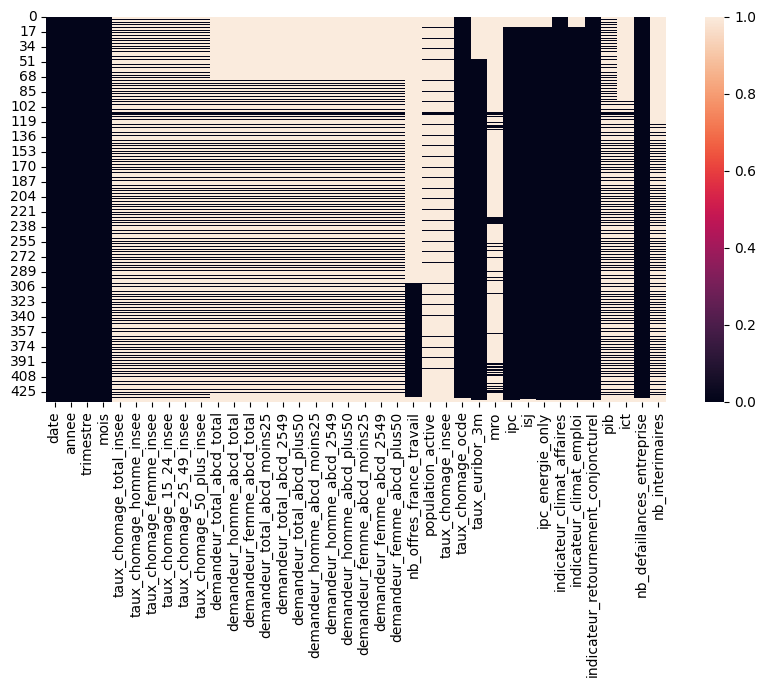

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isna());

### Traitement de la colonne "mro"

On propage le taux directeur (ponctuel) sur les mois suivants pour qu'il soit "actif" dans le calcul de la moyenne trimestrielle

In [11]:
df['mro'] = df['mro'].ffill()

### Définition des règles d'agrégation vers le trimestriel

In [12]:
cols_trim_prev = [
    'taux_chomage_total_insee', 'taux_chomage_homme_insee', 'taux_chomage_femme_insee',
    'taux_chomage_15_24_insee', 'taux_chomage_25_49_insee', 'taux_chomage_50_plus_insee',
    'demandeur_total_abcd_total', 'demandeur_homme_abcd_total', 'demandeur_femme_abcd_total',
    'demandeur_total_abcd_moins25', 'demandeur_total_abcd_2549', 'demandeur_total_abcd_plus50',
    'demandeur_homme_abcd_moins25', 'demandeur_homme_abcd_2549', 'demandeur_homme_abcd_plus50',
    'demandeur_femme_abcd_moins25', 'demandeur_femme_abcd_2549', 'demandeur_femme_abcd_plus50',
    'population_active', 'pib', 'ict', 'nb_interimaires'
]

In [13]:
# Agrégation selon la nature de la donnée
agg_dict = {}
for col in cols_trim_prev:
    if col in df.columns: agg_dict[col] = 'first'

In [14]:
# Variables mensuelles (Moyenne)
for col in ['taux_euribor_3m', 'mro', 'ipc', 'isj', 'ipc_energie_only', 'taux_chomage_ocde']:
    if col in df.columns: agg_dict[col] = 'mean'

In [15]:
# Variables de flux (Somme)
for col in ['nb_defaillances_entreprise', 'nb_offres_france_travail']:
    if col in df.columns: agg_dict[col] = 'sum'

In [16]:
# Variables de sentiment (Dernière valeur du trimestre)
for col in ['indicateur_climat_affaires', 'indicateur_climat_emploi', 'indicateur_retournement_conjoncturel']:
    if col in df.columns: agg_dict[col] = 'last'

### Passage au format Trimestriel (Resampling)

In [17]:
# 'QS' = Quarter Start (L'index sera le 01/01, 01/04, 01/07, 01/10)
df_q = df.set_index('date').resample('QS').agg(agg_dict)

In [18]:
df_q.head(10)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,mro,ipc,isj,ipc_energie_only,taux_chomage_ocde,nb_defaillances_entreprise,nb_offres_france_travail,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel
date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,8.1,6.3,10.3,16.9,6.9,5.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.500000,12117.0,0.0,111.5,NaN,0.9
1990-04-01,8.0,6.3,10.2,16.8,6.8,5.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.400000,11310.0,0.0,108.9,NaN,1.0
1990-07-01,8.0,6.3,10.1,16.7,6.8,5.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.300000,9416.0,0.0,102.8,NaN,-1.0
1990-10-01,8.0,6.3,10.0,16.9,6.8,5.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.300000,13286.0,0.0,98.8,NaN,-1.0
1991-01-01,7.9,6.3,10.0,17.0,6.8,5.2,NaN,NaN,NaN,NaN,...,NaN,3.333333,3.966667,5.233333,9.266667,14197.0,0.0,94.2,99.4,-0.9
1991-04-01,8.1,6.4,10.1,17.4,6.9,5.4,NaN,NaN,NaN,NaN,...,NaN,3.300000,3.900000,4.766667,9.433333,13286.0,0.0,93.9,91.6,-0.8
1991-07-01,8.3,6.6,10.3,17.7,7.1,5.6,NaN,NaN,NaN,NaN,...,NaN,3.200000,3.900000,1.633333,9.700000,10817.0,0.0,94.7,89.4,-0.9
1991-10-01,8.5,6.8,10.6,17.8,7.3,5.8,NaN,NaN,NaN,NaN,...,NaN,3.000000,3.800000,-2.433333,10.000000,14563.0,0.0,91.5,91.3,-1.0
1992-01-01,8.7,7.1,10.8,18.3,7.6,6.0,NaN,NaN,NaN,NaN,...,NaN,2.766667,3.533333,-1.233333,10.266667,15868.0,0.0,95.5,90.1,-1.0


### Feature Engineering

#### Population active

In [19]:
# Population active : interpolation linéaire pour passer de l'année aux trimestres
df_q['population_active'] = df_q['population_active'].interpolate(method='linear')

#### PIB

- L'argument mathématique (Stationnarité) : Le PIB en valeur brute (ex: 600 milliards €) est une série "non-stationnaire". Elle augmente presque toujours avec le temps. Si on l'utilise brute, un modèle risque de créer une corrélation artificielle simplement parce que les deux courbes montent. En calculant le taux de variation, on rend la donnée stationnaire, ce qui est indispensable pour la plupart des algorithmes.

- L'argument métier (Loi d'Okun) : Ce n'est pas la richesse totale d'un pays qui crée de l'emploi, c'est sa croissance. En économie, on observe qu'il faut un certain niveau de croissance trimestrielle pour stabiliser ou réduire le chômage.

In [20]:
# Croissance du PIB (Trimestre sur Trimestre)
df_q['pib_growth_qoq'] = df_q['pib'].pct_change()

#### Inflation : passage en glissement annuel
- L'argument mathématique (Saisonnalité) : Les prix varient selon les mois (soldes, énergie en hiver). En comparant l'indice T par rapport à T−4 (même trimestre de l'année précédente), on élimine naturellement ces effets saisonniers sans avoir besoin de calculs complexes.

- L'argument métier : C'est la mesure standard de l'inflation. Elle reflète le pouvoir d'achat réel. Une inflation trop forte peut freiner la consommation et donc augmenter le chômage à terme.

In [21]:
# Inflation réelle (Glissement annuel - comparaison avec T-4)
df_q['inflation_yoy'] = df_q['ipc'].pct_change(periods=4)

#### Taux de Chômage : passage en différence première

- L'argument mathématique (Autocorrélation) : Le taux de chômage est très "inerte". S'il est de 7,5% ce trimestre, il y a 99% de chances qu'il soit proche de 7,5% le mois prochain. Prédire la valeur brute est trop facile et n'apporte rien.

- L'argument métier : Ce qui intéresse le décideur, c'est de savoir si le chômage accélère, stagne ou recule. En prédisant la variation (Δ), on se concentre sur les points d'inflexion de l'économie.

In [22]:
# Variation du chômage (Cible : combien de points on gagne ou perd ce trimestre)
df_q['var_taux_chomage'] = df_q['taux_chomage_total_insee'].diff()

### Indices de Climat : standardisation

- L'argument mathématique (Mise à l'échelle) : Les indices de climat sont souvent basés sur 100, tandis que les taux d'intérêt sont entre 0 et 4. Si on les met ensemble dans un modèle sans transformation, le modèle donnera plus de poids aux variables ayant les plus gros chiffres (l'indice 100).

- L'argument métier : Le Z-score permet de répondre à la question : "La confiance des patrons est-elle exceptionnellement basse par rapport à l'histoire ?". Un score de -2 signifie que nous sommes dans une crise majeure (comme 2008 ou Covid), peu importe l'unité de mesure originale.

In [23]:
# Standardisation (Z-Score) du climat des affaires
# Permet de voir si on est historiquement au dessus ou en dessous de la normale
for col in ['indicateur_climat_affaires', 'indicateur_climat_emploi']:
    df_q[f'{col}_zscore'] = (df_q[col] - df_q[col].mean()) / df_q[col].std()

#### Climat des affaires : variable décalé (lag)
- L'argument mathématique (Causalité temporelle) : Dans une série temporelle, la cause (X) précède souvent l'effet (Y). Si on utilise les variables du même trimestre, on fait de la corrélation. Si on utilise X au trimestre précédent pour prédire Y aujourd'hui, on fait de la prédiction.

- L'argument métier (Délai de décision) : Un chef d'entreprise qui perd confiance (baisse du climat des affaires) ne licencie pas le jour même. Il y a un temps de latence administratif et social. Intégrer un lag permet au modèle de capter ce délai de réaction.

In [24]:
# Création de "Lags" (Variables décalées)
# Très important : le climat des affaires d'aujourd'hui prédit souvent le chômage de demain
df_q['climat_affaires_lag1'] = df_q['indicateur_climat_affaires'].shift(1)

## Ajustement des périodes

Afin d'harmoniser les périodes de toutes les colonnes

In [25]:
# Filtrage de la période  : 1er Janvier 2000 au 2ème trimestre 2025
df_q = df_q.loc['2000-01-01':'2025-07-01']

# Désactivation de la colonne "nb_offres_france_travail"

à noter que la variable Offres d'emploi France Travail (`nb_offres_france_travail`) ne débute qu'en 2015 :

| Titre (Variable) | Fréquence | Date début | Date fin |
| :--- | :--- | :--- | :--- |
...
| Offres d'emploi France Travail (`nb_offres_france_travail`) | Mensuelle | 01/01/2015 | 30/09/2025 |
...


Nous la sortons du dataset final.

In [26]:
df_final = df_q.drop(["nb_offres_france_travail"], axis=1)

### Nouveau résumé des valeurs manquantes

In [27]:
df_q.isna().sum()

taux_chomage_total_insee                0
taux_chomage_homme_insee                0
taux_chomage_femme_insee                0
taux_chomage_15_24_insee                0
taux_chomage_25_49_insee                0
taux_chomage_50_plus_insee              0
demandeur_total_abcd_total              1
demandeur_homme_abcd_total              1
demandeur_femme_abcd_total              1
demandeur_total_abcd_moins25            1
demandeur_total_abcd_2549               1
demandeur_total_abcd_plus50             1
demandeur_homme_abcd_moins25            1
demandeur_homme_abcd_2549               1
demandeur_homme_abcd_plus50             1
demandeur_femme_abcd_moins25            1
demandeur_femme_abcd_2549               1
demandeur_femme_abcd_plus50             1
population_active                       0
pib                                     0
ict                                     0
nb_interimaires                         0
taux_euribor_3m                         0
mro                               

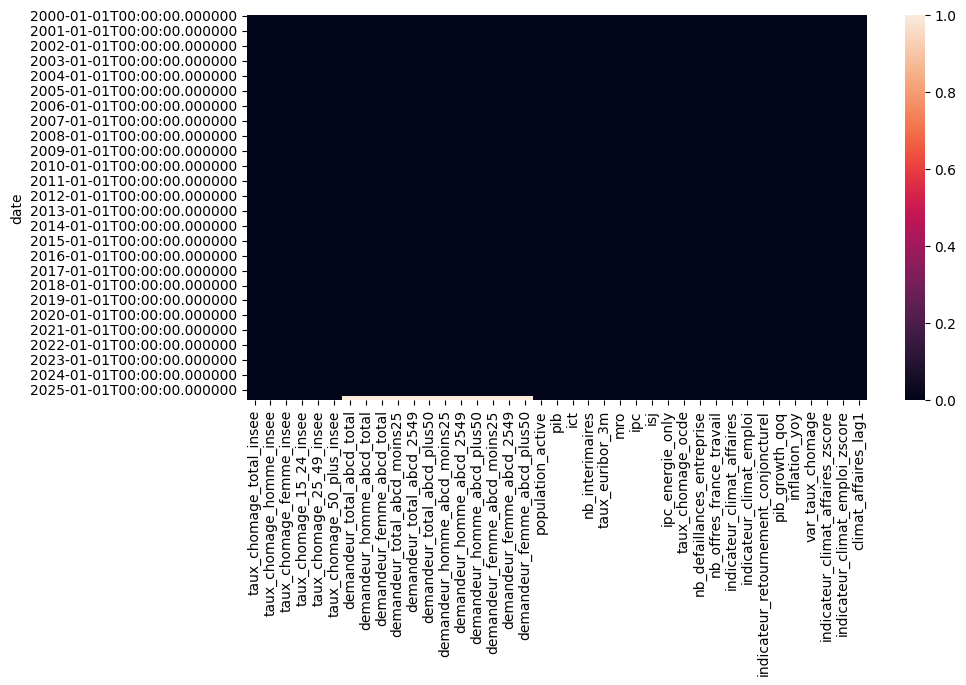

In [28]:
plt.figure(figsize=(10,5))
sns.heatmap(df_q.isna());

# Visualisation du dataframe final

In [29]:
df_final.tail(20)

,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,...,nb_defaillances_entreprise,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel,pib_growth_qoq,inflation_yoy,var_taux_chomage,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,climat_affaires_lag1
date,,,,,,,,,,,,,,,,,,,,,
2020-10-01,8.1,8.2,8.0,20.5,7.3,5.7,6025100.0,2919500.0,3105600.0,788700.0,...,7972.0,93.3,83.7,0.50,-0.000807,-0.939394,-0.9,-0.730861,-1.729002,93.8
2021-01-01,8.2,8.5,7.9,21.2,7.5,5.5,6026800.0,2918200.0,3108600.0,784200.0,...,7413.0,98.3,90.8,1.00,0.003943,-0.361111,0.1,-0.206529,-0.981448,93.3
2021-04-01,7.9,8.0,7.9,19.4,7.1,5.9,5975700.0,2889800.0,3085900.0,767900.0,...,6662.0,115.3,106.6,1.00,0.012079,3.555556,-0.3,1.576201,0.682125,98.3
2021-07-01,7.9,7.8,8.0,18.6,7.1,5.8,5845800.0,2823700.0,3022100.0,733000.0,...,5434.0,112.1,106.5,0.90,0.029949,4.300000,0.0,1.240628,0.671596,115.3
2021-10-01,7.4,7.5,7.3,16.5,6.7,5.7,5678000.0,2734900.0,2943100.0,694600.0,...,8073.0,110.8,110.4,0.90,0.005618,40.000000,-0.5,1.104302,1.082225,112.1
2022-01-01,7.4,7.4,7.4,16.8,6.7,5.5,5533100.0,2655900.0,2877200.0,670000.0,...,10047.0,107.3,113.7,-0.80,-0.000943,3.782609,0.0,0.737269,1.429680,110.8
2022-04-01,7.4,7.6,7.2,18.1,6.7,5.1,5450300.0,2614900.0,2835400.0,660300.0,...,9977.0,104.9,109.2,-0.20,0.004308,2.853659,0.0,0.485590,0.955877,107.3
2022-07-01,7.2,7.4,7.0,17.5,6.4,5.1,5432600.0,2608600.0,2824000.0,664500.0,...,9239.0,102.2,108.4,-0.20,0.005170,2.320755,-0.2,0.202450,0.871646,104.9
2022-10-01,7.1,7.3,6.9,16.9,6.4,5.0,5382600.0,2588100.0,2794500.0,661900.0,...,11978.0,103.4,110.1,-0.05,0.003875,1.231707,-0.1,0.328290,1.050638,102.2


# Export du nouveau dataset au format CSV

In [30]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"
chemin_export = repertoire_data_processed / "02_dataset_clean.csv"

df_final.to_csv(chemin_export, index=True, encoding='utf-8')

# BONUS : graphs

Corrélation calculée : 0.5244


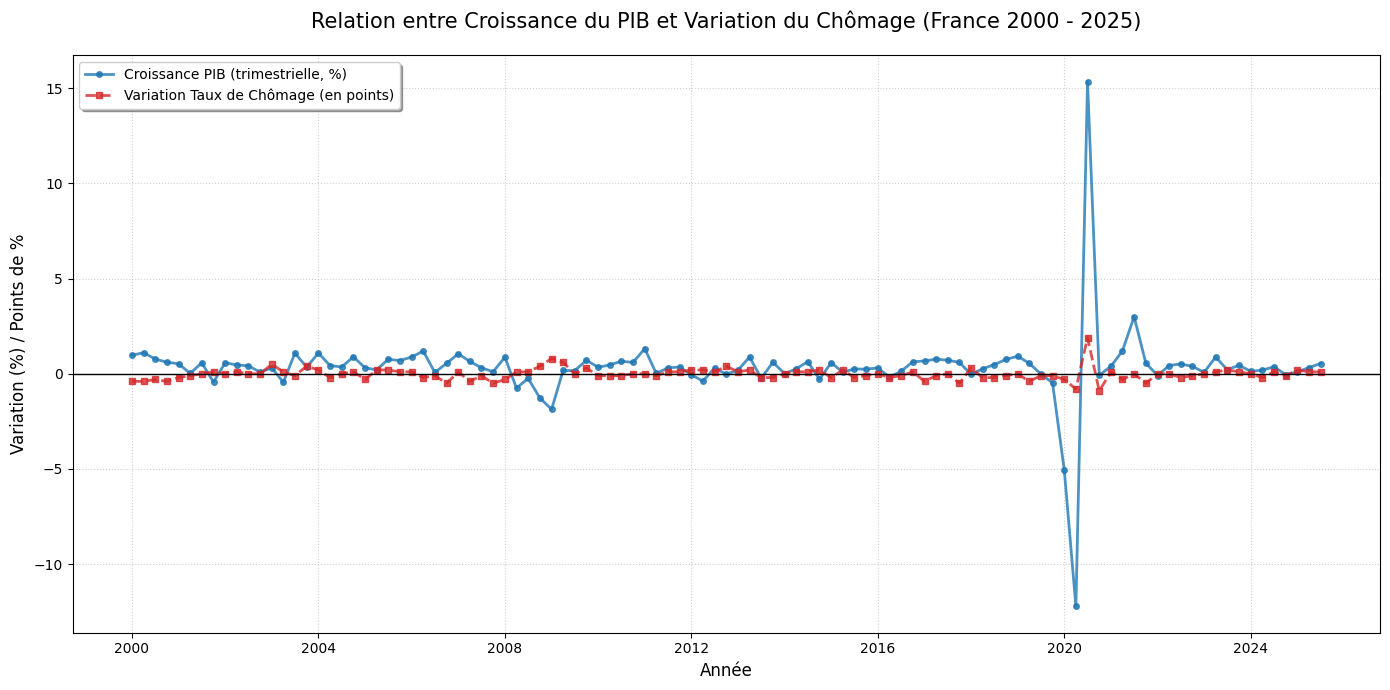

In [31]:
# 1. Préparation des données (on utilise le dataset df_q généré précédemment)
# Conversion de la croissance du PIB en pourcentage pour la lisibilité
pib_growth_pct = df_q['pib_growth_qoq'] * 100
var_chomage = df_q['var_taux_chomage']

# 2. Création du graphique
plt.figure(figsize=(14, 7))

# Tracé de la croissance du PIB
plt.plot(df_q.index, pib_growth_pct, label='Croissance PIB (trimestrielle, %)', 
         color='#1f77b4', linewidth=2, marker='o', markersize=4, alpha=0.8)

# Tracé de la variation du chômage
plt.plot(df_q.index, var_chomage, label='Variation Taux de Chômage (en points)', 
         color='#d62728', linestyle='--', linewidth=2, marker='s', markersize=4, alpha=0.8)

# Ajout d'une ligne horizontale à 0 (équilibre)
plt.axhline(0, color='black', linewidth=1, linestyle='-')

# 3. Personnalisation esthétique
plt.title('Relation entre Croissance du PIB et Variation du Chômage (France 2000 - 2025)', fontsize=15, pad=20)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Variation (%) / Points de %', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle=':', alpha=0.6)

# Optimisation de l'espace
plt.tight_layout()

# 4. Sauvegarde
plt.savefig('correlation_pib_chomage.png', dpi=300)

# Affichage de la corrélation calculée
correlation = pib_growth_pct.corr(var_chomage)
print(f"Corrélation calculée : {correlation:.4f}")

Analyse du graphique :

    Loi d'Okun inversée par les crises : En temps normal, une forte croissance (PIB > 0) entraîne une baisse du chômage (Variation < 0).

    Le choc COVID (2020-2021) : On observe des mouvements extrêmes. La chute brutale du PIB en 2020 n'a pas provoqué une explosion immédiate du chômage grâce aux mesures de chômage partiel. À l'inverse, le "rebond" technique de 2021 montre une corrélation positive atypique (0.53 sur l'ensemble de la période), car les indicateurs de chômage ont repris leurs niveaux normaux en même temps que l'activité.

    Signaux récents (2024-2025) : Les deux courbes se stabilisent autour de zéro, illustrant une phase de croissance molle et un chômage qui stagne ou remonte légèrement.